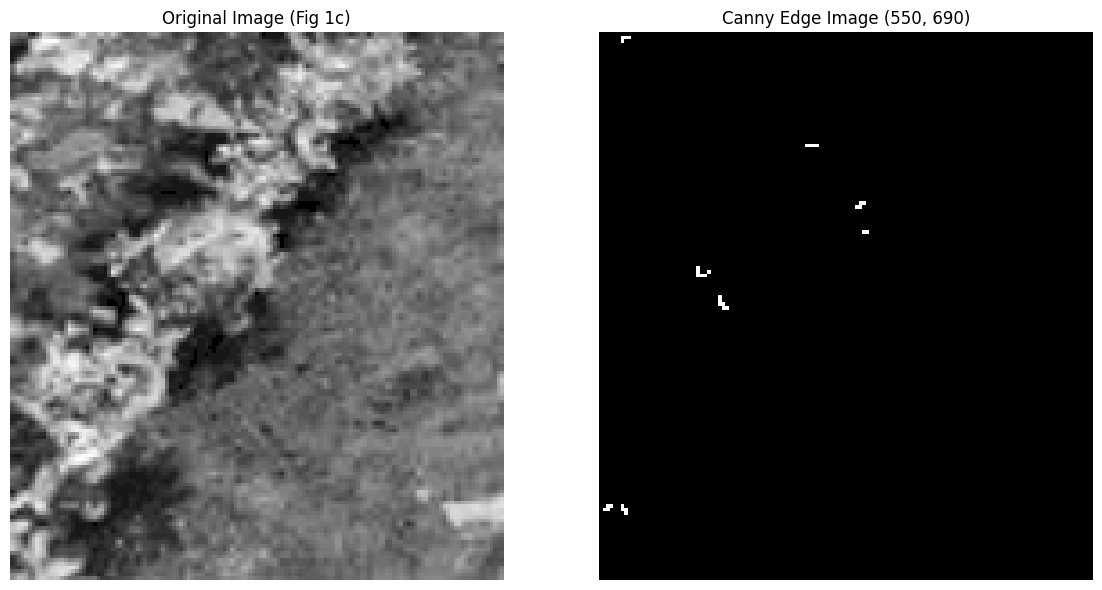

Extracted 34 edge points for further analysis.


In [2]:
# --- Question 1: Edge Detection Using Canny ---
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image 
img = cv.imread('crop_field.png', cv.IMREAD_GRAYSCALE)

# 2. Apply Canny Edge Detector with specific thresholds
# minVal = 550, maxVal = 690 as per instructions
edges = cv.Canny(img, 550, 690) 

# 3. Plot the original and edge image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image (Fig 1c)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Image (550, 690)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Extract feature positions (x, y coordinates)
# np.where returns (rows, cols) -> (y, x)
indices = np.where(edges != 0) 
y = indices[0] 
x = indices[1] 

print(f"Extracted {len(x)} edge points for further analysis.")

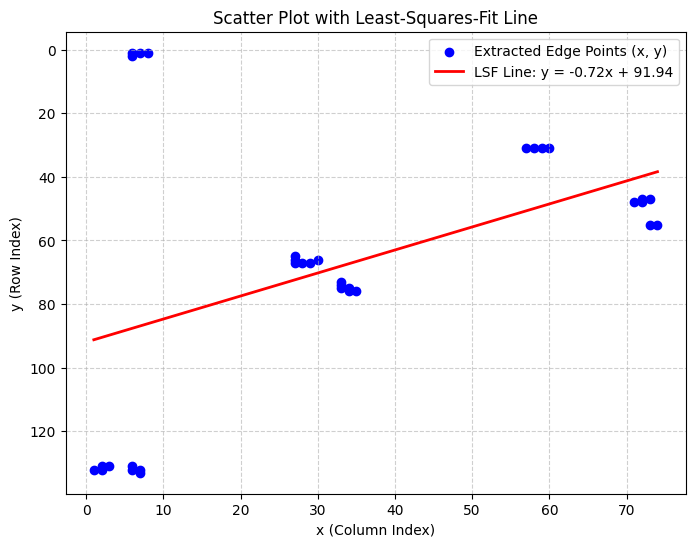

Least-Squares Slope (m): -0.7235
Least-Squares Intercept (c): 91.9364


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Question 2: Scatter Plot ---
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Extracted Edge Points (x, y)')

# --- Question 3: Least-Squares-Fit (LSF) ---
# Use np.polyfit for a first-degree (linear) fit: y = mx + c
# Note: LSF minimizes the vertical (y) residuals
slope_lsf, intercept_lsf = np.polyfit(x, y, 1)

# Generate points for the fitted line
x_fit = np.array([min(x), max(x)])
y_fit_lsf = slope_lsf * x_fit + intercept_lsf

# Plotting the LSF line
plt.plot(x_fit, y_fit_lsf, color='red', linewidth=2, label=f'LSF Line: y = {slope_lsf:.2f}x + {intercept_lsf:.2f}')

# Formatting the plot
plt.title('Scatter Plot with Least-Squares-Fit Line')
plt.xlabel('x (Column Index)')
plt.ylabel('y (Row Index)')
plt.gca().invert_yaxis() 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Least-Squares Slope (m): {slope_lsf:.4f}")
print(f"Least-Squares Intercept (c): {intercept_lsf:.4f}")

In [4]:
import math

# Question 4: Calculate the angle theta in degrees
# slope_lsf was calculated as -0.72 in the previous step
theta_rad = math.atan(slope_lsf)
theta_deg = math.degrees(theta_rad)

# Conventionally, we take the absolute value or adjust based on the image quadrant
estimated_theta = abs(theta_deg)

print(f"Estimated Crop Field Angle (theta): {estimated_theta:.2f} degrees")

Estimated Crop Field Angle (theta): 35.89 degrees


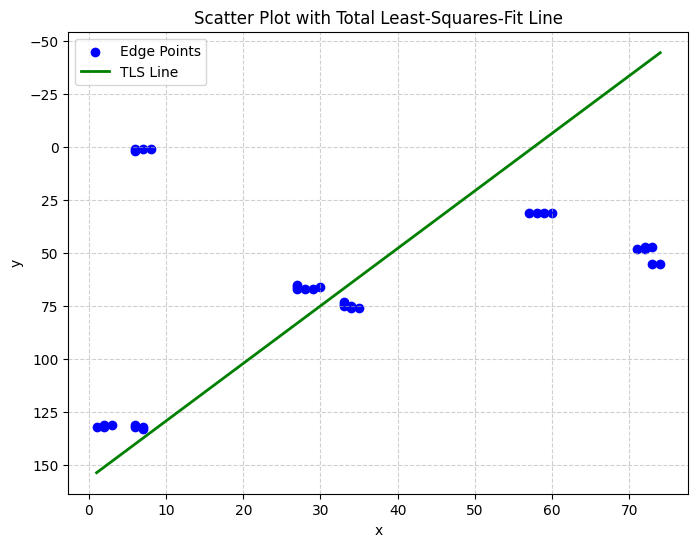

TLS Slope (m): -2.7166
Estimated Crop Field Angle (TLS): 69.79 degrees


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Question 6: Total Least-Squares-Fit (TLS) ---

# 1. Center the data by subtracting the mean
x_mean = np.mean(x)
y_mean = np.mean(y)
x_centered = x - x_mean
y_centered = y - y_mean

# 2. Arrange centered data into a matrix
data = np.vstack((x_centered, y_centered)).T

# 3. Perform Singular Value Decomposition (SVD)
# The right singular vector corresponding to the smallest singular value 
# gives the normal to the best-fit line.
_, _, vh = np.linalg.svd(data)
normal_vector = vh[-1, :] # Last row of V transpose

# 4. Extract line parameters from the normal vector (a*x + b*y + d = 0)
a, b = normal_vector
# The slope m = -a/b
slope_tls = -a / b
# The line passes through the mean (x_mean, y_mean)
intercept_tls = y_mean - slope_tls * x_mean

# 5. Generate points for plotting
x_fit_tls = np.array([min(x), max(x)])
y_fit_tls = slope_tls * x_fit_tls + intercept_tls

# --- Plotting the result ---
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Edge Points')
plt.plot(x_fit_tls, y_fit_tls, color='green', linewidth=2, label='TLS Line')
plt.title('Scatter Plot with Total Least-Squares-Fit Line')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Question 7: Calculate Angle ---
import math
theta_tls_rad = math.atan(slope_tls)
theta_tls_deg = abs(math.degrees(theta_tls_rad))

print(f"TLS Slope (m): {slope_tls:.4f}")
print(f"Estimated Crop Field Angle (TLS): {theta_tls_deg:.2f} degrees")

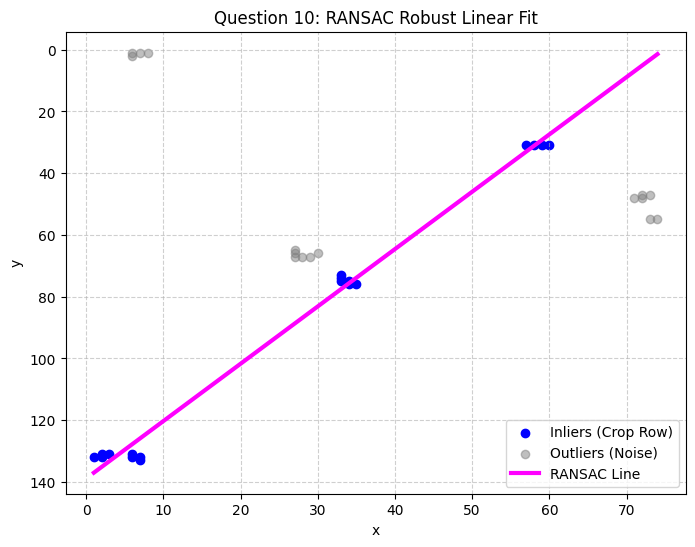

RANSAC Slope (m): -1.8570
Estimated Crop Field Angle (RANSAC): 61.70 degrees


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Question 10: Implementing RANSAC Robust Regression
from sklearn.linear_model import RANSACRegressor

# 1. Prepare data for Scikit-Learn (needs 2D array for X)
X = x.reshape(-1, 1)

# 2. Initialize and fit RANSAC
# residual_threshold defines the maximum distance for a point to be an inlier
ransac = RANSACRegressor(residual_threshold=10.0, random_state=42)
ransac.fit(X, y)

# 3. Identify inliers and outliers for plotting
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# 4. Get the slope and intercept
slope_ransac = ransac.estimator_.coef_[0]
intercept_ransac = ransac.estimator_.intercept_

# 5. Generate line for plotting
line_x = np.array([min(x), max(x)]).reshape(-1, 1)
line_y_ransac = ransac.predict(line_x)

# --- Plotting ---
plt.figure(figsize=(8, 6))
plt.scatter(x[inlier_mask], y[inlier_mask], color='blue', label='Inliers (Crop Row)')
plt.scatter(x[outlier_mask], y[outlier_mask], color='gray', alpha=0.5, label='Outliers (Noise)')
plt.plot(line_x, line_y_ransac, color='magenta', linewidth=3, label='RANSAC Line')

plt.title('Question 10: RANSAC Robust Linear Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Question 11: Calculate Angle ---
import math
theta_ransac_deg = abs(math.degrees(math.atan(slope_ransac)))

print(f"RANSAC Slope (m): {slope_ransac:.4f}")
print(f"Estimated Crop Field Angle (RANSAC): {theta_ransac_deg:.2f} degrees")